## 1. Imports and Helper Functions

Import libraries, load helper functions for bandpass filtering, sliding standard deviation, and FWHM calculation.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import sys
import os
import fnmatch
from numpy import std

sys.path.append(os.path.join(os.path.dirname(os.path.abspath('__file__')), ''))
from importrhdutilities import load_file
from load_intan_rhs import read_data
from scipy.signal import butter, filtfilt, fftconvolve,find_peaks, peak_widths

from sklearn.cluster import DBSCAN
from scipy.interpolate import interp1d
from scipy.ndimage import uniform_filter1d

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap

In [2]:
def butter_bandpass(lowcut, highcut, fs, order=3):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a
def butter_bandpass_filter(data, lowcut, highcut, fs, order=3):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y
def sliding_std(filtered_dat,sliding_win_size=30000):
    kernel = np.ones( (sliding_win_size,1 ))/sliding_win_size #average counter
    sig=filtered_dat.T
    sliding_means = fftconvolve(sig,kernel,mode='same')
    sig_ = sig-sliding_means
    sliding_stds = np.sqrt( fftconvolve(sig_*sig_, kernel, mode='same'))
    return sliding_stds, sliding_means

def FWHM(signal):
    half_max = np.max(abs(signal)) / 2
    indices = np.where(abs(signal) >= half_max)[0]

    fwhm_samples = indices[-1] - indices[0]
    fwhm_real = fwhm_samples / fs *1000  # Convert to milliseconds
    return fwhm_real

## 2. Parameters and File Paths

# Update these paths to point to your data. Example data is in Intan_output_example/.

In [3]:
peakwidth = 80  # minimum width of a peak in datapoints (samples at fs=30000)
fs = 30000  # Sampling frequency in Hz
std_threshold = 5  # threshold for spike detection (multiples of local std)
bps = [300, 6000]  # Bandpass filter passband in Hz [low, high]

# --- Example data (runs as-is) ---
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
example_dir = os.path.join(BASE_DIR, 'Intan_output_example',
                           'organoid_stim_scope_fewer_electrodes_50micro_amp_260216_154348')
experiment_name = 'example'
out_dir = os.path.join(BASE_DIR, 'example_output')
os.makedirs(out_dir, exist_ok=True)
save_svg = False
filename_1 = os.path.join(example_dir, 'organoid_stim_scope_fewer_electrodes_50micro_amp_260216_154348.rhs')
filename_2 = os.path.join(example_dir, 'organoid_stim_scope_fewer_electrodes_50micro_amp_260216_154448.rhs')
filename_3 = os.path.join(example_dir, 'organoid_stim_scope_fewer_electrodes_50micro_amp_260216_154548.rhs')

#information about the start time of the electrical and optical recordings, in seconds, can be found in experimental_setup.txt
electrical_start = 48.800631
optical_start = 50.125

## 3. Load Recording Data

Load `.rhs` file(s) using `read_data`. For multi-file recordings, uncomment `recording_2` / `recording_3` lines and concatenate below.

In [4]:
recording_1 = read_data(filename_1)
recording_2 = read_data(filename_2)
recording_3 = read_data(filename_3)


Reading Intan Technologies RHS Data File, Version 3.3

Found 21 amplifier channels.
Found 0 board ADC channels.
Found 0 board DAC channels.
Found 0 board digital input channels.
Found 0 board digital output channels.

File contains 60.002 seconds of data.  Amplifiers were sampled at 30.00 kS/s.
FINISHED HEADER

Allocating memory for data...
Reading data from file...
10% done...
20% done...
30% done...
40% done...
50% done...
60% done...
70% done...
80% done...
90% done...
Parsing data...
No missing timestamps in data.
Done!  Elapsed time: 0.9 seconds

Reading Intan Technologies RHS Data File, Version 3.3

Found 21 amplifier channels.
Found 0 board ADC channels.
Found 0 board DAC channels.
Found 0 board digital input channels.
Found 0 board digital output channels.

File contains 60.002 seconds of data.  Amplifiers were sampled at 30.00 kS/s.
FINISHED HEADER

Allocating memory for data...
Reading data from file...
10% done...
20% done...
30% done...
40% done...
50% done...
60% done...


In [5]:
#combine three recordings
amplifier_data = np.concatenate((
    recording_1['amplifier_data'],
    recording_2['amplifier_data'],
    recording_3['amplifier_data']
), axis=1)
num_electrodes = amplifier_data.shape[0]
print(f"number of electrodes: {num_electrodes}")
print(f"original electrical recording length: {amplifier_data.shape[1] / fs:.3f} seconds")

number of electrodes: 21
original electrical recording length: 125.022 seconds


## 4. Build Electrode Dictionary

Extract channel names from the recording metadata and map them to integer indices.

In [6]:
electrodes_label_list = recording_1['amplifier_channels']

#extract native channel names and map to electrode numbers
electrodes_dict = {}
for i in range(num_electrodes):
    channel_obj = electrodes_label_list[i]
    # Access native_channel_name from the channel object
    native_name = channel_obj['native_channel_name']
    electrodes_dict[i] = native_name

## 5. Stimulation Detection

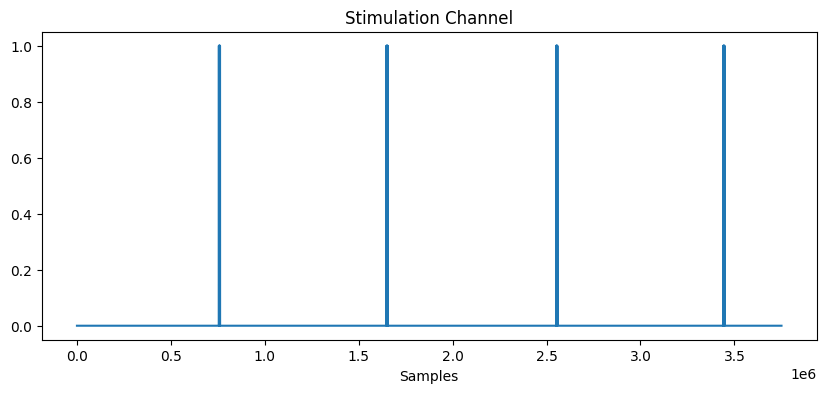

In [7]:
#check if stimulation is recorded
stim_channel_index = 1  #one of the B channels in purple group A for blue

#For multi-file recordings, concatenate stim_data from each recording:
stim_data = np.concatenate((
    recording_1['stim_data'][stim_channel_index,],
    recording_2['stim_data'][stim_channel_index,],
    recording_3['stim_data'][stim_channel_index,]
))
stim_data_bin = (stim_data > 0).astype(int)

plt.figure(figsize=(10, 4))
plt.plot(stim_data_bin)
plt.title('Stimulation Channel')
plt.xlabel('Samples')
plt.show()

> **Optional — Timestamp Alignment:** The cell below aligns the electrical recording to an optical recording by trimming or padding samples. Skip this cell if you are not co-analyzing optical data.

In [8]:
# Skip this cell if not aligning with an optical recording
if "optical_start" in globals() and "electrical_start" in globals():
    diff = optical_start - electrical_start
    print(f"Time difference: {diff:.3f} s")
    if diff > 0:
        samples_to_remove = int(diff * fs)
        amplifier_data = amplifier_data[:, samples_to_remove:]
        stim_data_bin  = stim_data_bin[samples_to_remove:]
    else:
        samples_to_add = int(-diff * fs)
        amplifier_data = np.hstack((np.zeros((num_electrodes, samples_to_add)), amplifier_data))
        stim_data_bin  = np.hstack((np.zeros(samples_to_add), stim_data_bin))
    print(f"New electrical recording length: {amplifier_data.shape[1] / fs:.3f} seconds")
else:
    print("Skipping timestamp alignment (optical_start/electrical_start not set)")


Time difference: 1.324 s
New electrical recording length: 123.698 seconds


In [9]:
# extract stimulation windows from stimulation bin and add padding
number_of_pulses = 5
stim_frequency = 20  # Hz
pulse_length_ms = 100

idx = np.flatnonzero(stim_data_bin)
stim_duration = number_of_pulses * pulse_length_ms * 1e-3 * fs
print(f"Initial calculated stimulation duration in samples (based on pulse length): {stim_duration}")
#consider pulse frequency
max_duration = number_of_pulses / stim_frequency * fs
print(f"Calculated maximum stimulation duration in samples (based on pulse frequency): {max_duration}")
stim_duration = max(stim_duration, max_duration)
print(f"Calculated stimulation duration in samples: {stim_duration}")

breaks = np.flatnonzero(np.diff(idx) > stim_duration)
run_starts = np.r_[idx[0], idx[breaks + 1]]
run_ends = np.r_[idx[breaks], idx[-1]] + 1

# build stimulation windows with padding (in samples)
pad_ms = 500
pad = int(round(pad_ms * 1e-3 * fs))
n = stim_data_bin.size
stim_windows = [(max(0, s - pad), min(n, e + pad)) for s, e in zip(run_starts, run_ends)]

for i, (start, end) in enumerate(stim_windows):
    print(f"Window {i+1}: Start = {start/fs:.3f} s, End = {end/fs:.3f} s, Duration = {(end-start)/fs*1000:.3f} ms")

Initial calculated stimulation duration in samples (based on pulse length): 15000.0
Calculated maximum stimulation duration in samples (based on pulse frequency): 7500.0
Calculated stimulation duration in samples: 15000.0
Window 1: Start = 23.355 s, End = 24.560 s, Duration = 1205.133 ms
Window 2: Start = 53.095 s, End = 54.300 s, Duration = 1205.133 ms
Window 3: Start = 83.214 s, End = 84.419 s, Duration = 1205.133 ms
Window 4: Start = 112.867 s, End = 114.072 s, Duration = 1205.133 ms


In [10]:
def interpolate_window_1d(x, start, end):
    x = x.copy()
    n = x.size
    if start <= 0 or end >= n:
        fill = x[start-1] if start > 0 else x[end] if end < n else 0.0
        x[start:end] = fill
        return x
    x0, x1 = x[start-1], x[end]
    x[start:end] = np.linspace(x0, x1, end-start, endpoint=False)
    return x

def remove_artifacts_multiple_windows(amp, windows):
    amp_clean = amp.copy()
    for ch in range(amp.shape[0]):
        x = amp_clean[ch]
        for s, e in windows:
            x = interpolate_window_1d(x, s, e)
        amp_clean[ch] = x
    return amp_clean

In [11]:
#remove stimulation artifact by removing peaks happening at the same time as stimulation
artifact_removed_data = remove_artifacts_multiple_windows(amplifier_data, stim_windows)

## 7. Bandpass Filtering

Apply bandpass filter using SpikeInterface preprocessing. Adjust `bps` in Section 2 to change the passband.

In [12]:
#spikeinterface preprocessing   
import spikeinterface.extractors as se
arr = artifact_removed_data.astype('float32')  
recording_spikeint = se.NumpyRecording(
    traces_list=[arr.T],
    sampling_frequency=fs
)

from spikeinterface.preprocessing import bandpass_filter, common_reference, unsigned_to_signed
#spikeinterface preprocessing
recording_f = bandpass_filter(recording_spikeint, freq_min=bps[0], freq_max=bps[1])
recording_cmr = common_reference(recording_f, operator='median')
filtdata = recording_cmr.get_traces()
filtdata = filtdata.T  #shape to channels x timepoints

#calcualte channel std
channel_std = np.std(filtdata, axis=1)

/opt/anaconda3/envs/spikeinterface/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
# delete raw data to save memory
del recording_1
del amplifier_data
del arr

In [14]:
#print the max and min value in each channel
for i, electrode_num in enumerate(electrodes_dict.keys()):
    print(f'Electrode {electrode_num} Port {electrodes_dict[electrode_num]}: max={np.max(filtdata[i])}, min={np.min(filtdata[i])}')


Electrode 0 Port A-008: max=144.837890625, min=-120.40418243408203
Electrode 1 Port A-009: max=85.16429138183594, min=-97.74930572509766
Electrode 2 Port A-010: max=350.9648742675781, min=-474.3341369628906
Electrode 3 Port A-011: max=86.08995056152344, min=-147.4587860107422
Electrode 4 Port A-016: max=177.911865234375, min=-191.64199829101562
Electrode 5 Port A-017: max=61.14544677734375, min=-22.60759735107422
Electrode 6 Port A-018: max=39.91300582885742, min=-13.726810455322266
Electrode 7 Port A-019: max=45.39698791503906, min=-38.744110107421875
Electrode 8 Port A-020: max=36.95560836791992, min=-14.926332473754883
Electrode 9 Port A-021: max=29.0386962890625, min=-16.679912567138672
Electrode 10 Port A-022: max=18.396469116210938, min=-27.400604248046875
Electrode 11 Port A-029: max=178.7880401611328, min=-190.33885192871094
Electrode 12 Port A-030: max=100.37694549560547, min=-122.5789566040039
Electrode 13 Port A-031: max=178.58538818359375, min=-197.63807678222656
Electrode 

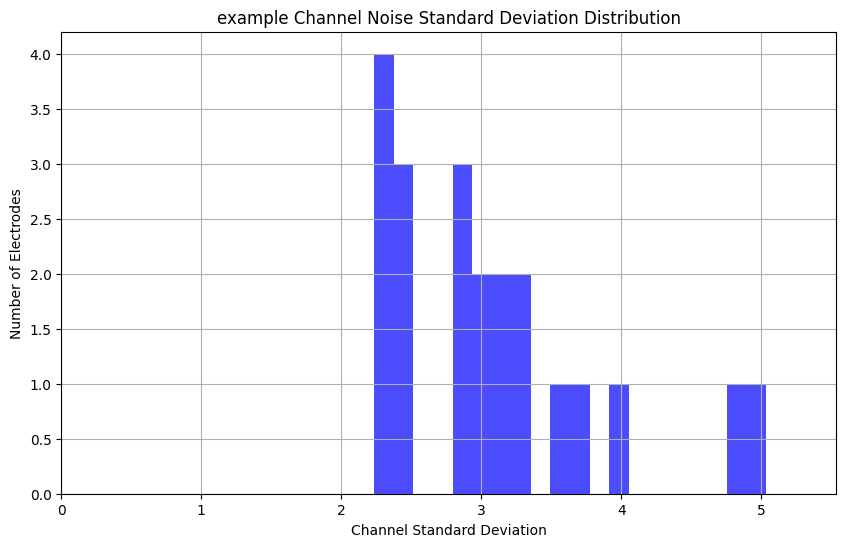

In [15]:
#plot the channel std distribution
plt.figure(figsize=(10, 6))
plt.hist(channel_std, bins=20, color='blue', alpha=0.7)
plt.xlim(0, np.max(channel_std)*1.1)
plt.xlabel('Channel Standard Deviation')
plt.ylabel('Number of Electrodes')
plt.title(f'{experiment_name} Channel Noise Standard Deviation Distribution')
plt.savefig(os.path.join(out_dir, f'{experiment_name}_channel_std_distribution.png'), dpi=300)
plt.grid()
plt.show()

In [16]:
# calcualate sliding window std
std_local, mean_local = sliding_std(filtdata, sliding_win_size=fs)

## 8. Visualize Raw Traces

Plot filtered traces for all channels with the local threshold overlay.

In [17]:
num_electrodes_plot = len(filtdata)  # use actual channel count
start_frame = 10 * 30000
end_frame = start_frame + 100 * 30000

x = np.linspace(start_frame, end_frame, end_frame - start_frame) / 30000
num_figures = 6
electrodes_subsets = [list(range(i, min(i + num_figures, num_electrodes_plot)))
                      for i in range(0, num_electrodes_plot, num_figures)]

for subset_idx, subset in enumerate(electrodes_subsets):
    fig, axs = plt.subplots(len(subset), 1, figsize=(15, 10), sharex=True)
    if len(subset) == 1:
        axs = [axs]
    for ax, electrode in zip(axs, subset):
        real_electrode_num = list(electrodes_dict.keys())[electrode]
        sig      = filtdata[electrode, start_frame:end_frame]
        mean_sig = mean_local[start_frame:end_frame, electrode]
        std_sig  = std_local[start_frame:end_frame, electrode]
        ax.plot(x, sig, lw=0.5)
        ax.plot(x, mean_sig + std_threshold * std_sig, color="orange", lw=0.5, label="Local Std")
        ax.plot(x, mean_sig - std_threshold * std_sig, color="orange", lw=0.5)
        ax.set_title(f"Electrode {real_electrode_num} Port {electrodes_dict[real_electrode_num]}")
        ax.grid()
    axs[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    save_path = os.path.join(out_dir, f"{experiment_name}_all_chunk_threshold{subset_idx+1}.png")
    fig.savefig(save_path, dpi=300)
    plt.close(fig)


## 9. Spike Detection

Detect negative and positive peaks channel-by-channel using a local standard-deviation threshold.

In [18]:
#sort spikes
peakwidth=80
pre=40 #2 ms before peak
pst=40 #2 ms after peak
all_chan_peaks=[]
for idx in range(len(filtdata)):
    ##if using local standard deviation per channel, use:
    mean_subtracted_data = filtdata[idx] - mean_local[:,idx]
    p,_=find_peaks(np.abs(mean_subtracted_data), height=std_threshold*std_local[:,idx], distance=peakwidth)
    ##if using fixed standard deviation per channel, use:
    # mean_subtracted_data = filtdata[idx] - np.mean(filtdata[idx])
    # p,_=find_peaks(np.abs(mean_subtracted_data), height=std_threshold*channel_std_valid[idx], distance=peakwidth)
    all_chan_peaks.append(np.vstack((np.ones(len(p))*idx,p)).T)
all_chan_peaks=np.concatenate(all_chan_peaks).astype(int) 

snips=[]
for chan,pix in all_chan_peaks:
    snips.append(filtdata[chan][pix-pre:pix+pst])

#keep timestamp of only snips greater than 90 
valid_waveidx = np.where(np.array([len(snip) for snip in snips]) == peakwidth)[0]
#and not happening at the end and beginning of the recording
valid_waveidx = valid_waveidx[np.where(all_chan_peaks[valid_waveidx, 1] > peakwidth*2)]
valid_waveidx = valid_waveidx[np.where(all_chan_peaks[valid_waveidx, 1] < len(filtdata[0]) - peakwidth*2)]

#update all chan peaks and snip with valid indices
all_chan_peaks = all_chan_peaks[valid_waveidx]
snips = [snips[i] for i in valid_waveidx]
snips=np.asarray(snips)

print("number of total snips:", all_chan_peaks.shape[0])

number of total snips: 1535


## 10. Spike Cleanup

Remove spikes from reference channels and spikes that fall within stimulation windows.

In [19]:
ref_channel = []  # list of channel names to exclude, e.g. ['A-016', 'A-029']
#remove snips in reference channels
ref_channel_indices = [i for i, name in electrodes_dict.items() if name in ref_channel]
ref_mask = np.isin(all_chan_peaks[:, 0], ref_channel_indices)
all_chan_peaks = all_chan_peaks[~ref_mask]
snips = snips[~ref_mask]

#if using artifact removal
#remove snips including stimulation timestamps
def is_in_stim_window(peak_time, windows):
    return any(start <= peak_time < end for start, end in windows)

exclude_mask = np.array([
    not is_in_stim_window(peak_time, stim_windows)
    for peak_time in all_chan_peaks[:, 1]
])

# Filter snips and peaks
all_chan_peaks_clean = all_chan_peaks[exclude_mask]
snips_clean = snips[exclude_mask]

print("number of total snips after cleanup:", all_chan_peaks.shape[0])

number of total snips after cleanup: 1535


## 11. Raster Plot

Plot all detected spikes as dots in a channel-vs-time raster.

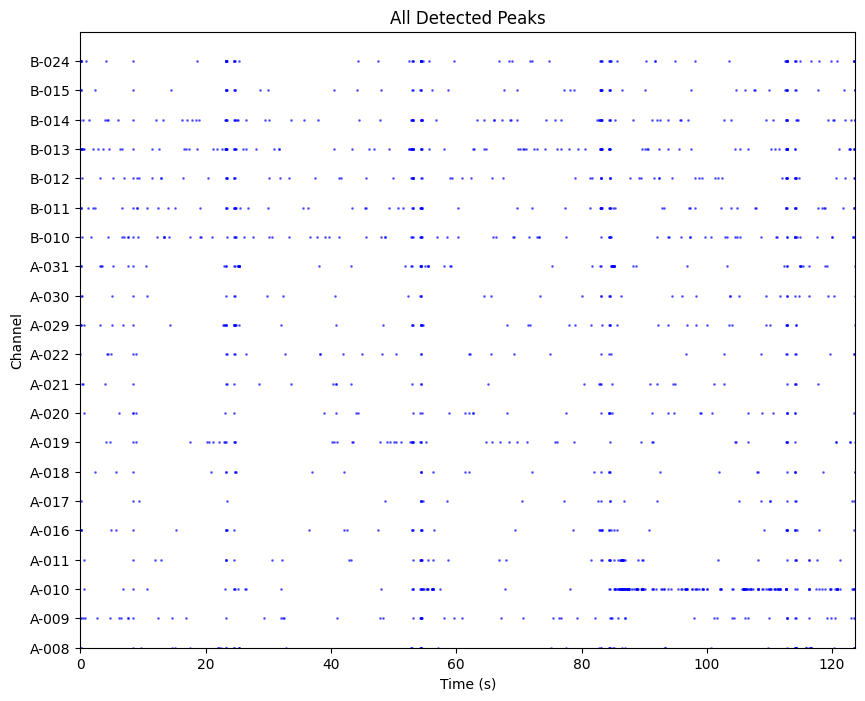

In [20]:
#plot all peaks as dots in channel vs time 2d plot
plot_stim_window = True
plt.figure(figsize=(10, 8))
#convert sample to time in seconds
time = all_chan_peaks[:,1]/fs
plt.scatter(time, all_chan_peaks[:,0], s=1, c='blue', alpha=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Channel')
#set y tick to show electrode number and port
yticks = np.arange(num_electrodes)
ytick_labels = [f'{electrodes_dict[i]}' for i in electrodes_dict.keys()]
plt.yticks(yticks, ytick_labels)
plt.title('All Detected Peaks')
plt.xlim(0, len(filtdata[0])/fs)
plt.ylim(0, len(filtdata))
# #if plotting stimulation windows
# if plot_stim_window:
#     for start, end in stim_windows:
#         plt.axvspan(start/fs, end/fs, color='red', alpha=0.2)
save_path = os.path.join(out_dir, f"{experiment_name}_raster_plot.png")
plt.savefig(save_path, dpi=300)
# if save_svg:
#     save_path_svg = os.path.join(out_dir, f"{experiment_name}_raster_plot.svg")
#     plt.savefig(save_path_svg)
plt.show()

## 12. Waveform Clustering (PCA + K-Means)

Project all spike waveforms into PCA space and cluster with K-Means.

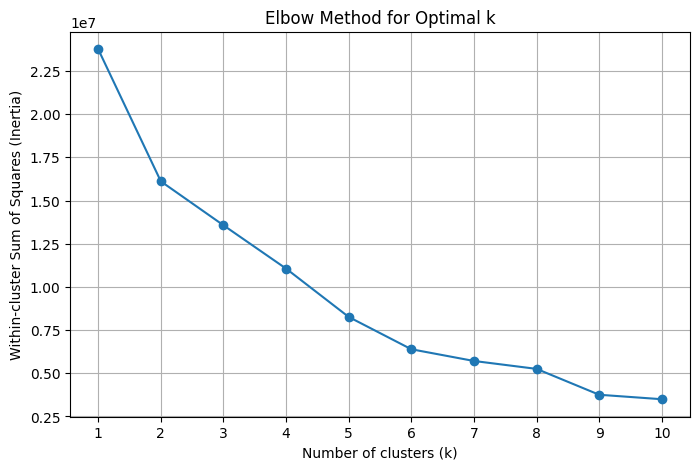

In [21]:
# global waveform clustering using PCA and k-means
pca = PCA(n_components=2)
pca_projections = pca.fit_transform(snips)
#find the optimal number of clusters using elbow method
#calculate inertia for kmeans with k from 1 to 10
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(pca_projections)
    inertia.append(kmeans.inertia_)

#ploting elblow method
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-cluster Sum of Squares (Inertia)')
plt.xticks(K)
plt.grid()
plt.show()

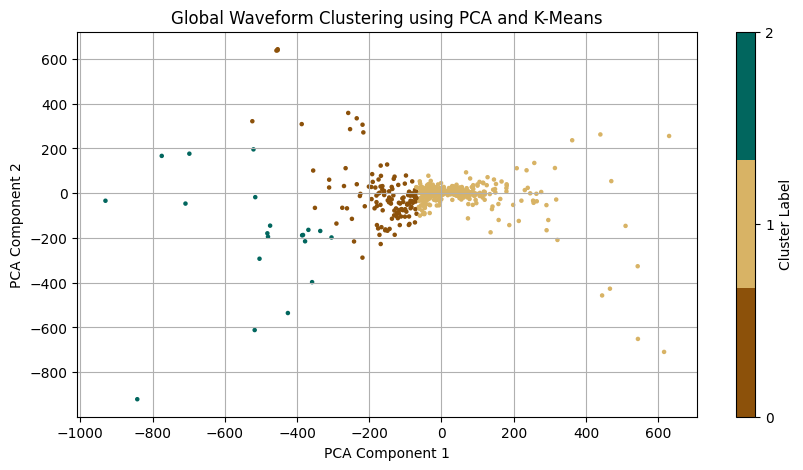

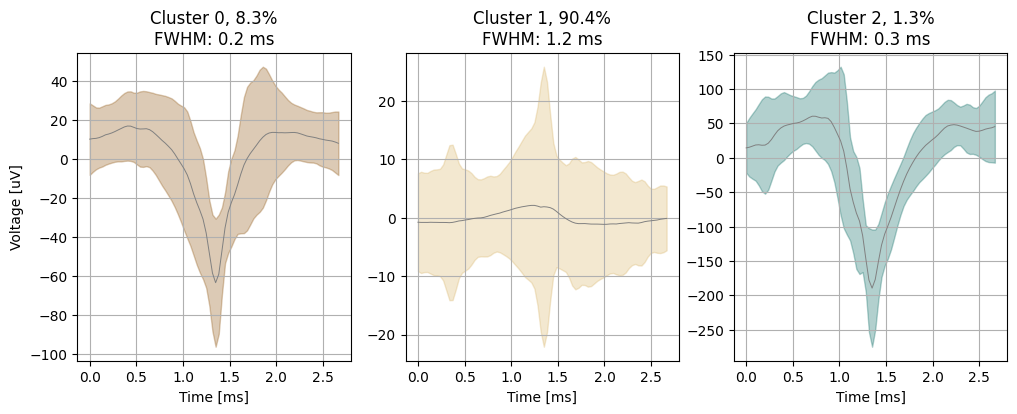

In [22]:
nclusters = 3# Number of clusters for k-means
#manully define a colormap
set_of_colors = ['#8c510a', '#d8b365', '#01665e', '#5ab4ac','#c51b7d','#4d9221', '#762a83', '#1b7837', '#9970ab', '#238b45']
cmap = ListedColormap(set_of_colors[0:nclusters])

kmeans = KMeans(n_clusters=nclusters, random_state=0).fit(pca_projections)
kmeans_labels = kmeans.labels_
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.scatter(pca_projections[:, 0], pca_projections[:, 1], c=kmeans_labels, s=5)
ax.set_title('Global Waveform Clustering using PCA and K-Means')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.collections[0].set_cmap(cmap)
ax.collections[0].set_array(kmeans_labels)
ax.collections[0].set_clim(0, nclusters - 1)
#show colorbar
cbar = plt.colorbar(ax.collections[0], ax=ax, ticks=np.arange(nclusters))
cbar.set_label('Cluster Label')
ax.grid()
#save figure
save_path = os.path.join(out_dir, f"{experiment_name}_PCA.png")
fig.savefig(save_path, dpi=300)
# if save_svg:
#     save_path_svg = os.path.join(out_dir, f"{experiment_name}_PCA.svg")
#     fig.savefig(save_path_svg)
plt.show()

#plot the mean and std for each k means cluster
fig,ax=plt.subplots(1,nclusters, figsize=(nclusters*4,4),sharex=True)

for i in range(nclusters):
    avg = np.mean(snips[kmeans_labels == i], axis=0)
    std = np.std(snips[kmeans_labels == i], axis=0)
    fwhm = FWHM(avg)  # FWHM in milliseconds
    l = len(snips[0])
    x = np.linspace(0, l, l) / fs * 1000  # ms
    ax[i].fill_between(x, y1=avg - std, y2=avg + std, alpha=0.3, color=cmap(i))
    ax[i].plot(x, avg, color='gray', linewidth=0.7)
    ax[i].set_title(f"Cluster {i}, {np.round(100 * np.sum(kmeans_labels == i) / len(kmeans_labels), 1)}%\n" f"FWHM: {np.round(fwhm, 1)} ms")
    ax[i].set_xlabel('Time [ms]')
    ax[0].set_ylabel('Voltage [uV]')
    ax[i].grid()
#save figure
save_path = os.path.join(out_dir, f"{experiment_name}_waveforms.png")
fig.savefig(save_path, dpi=300)
# if save_svg:
#     save_path_svg = os.path.join(out_dir, f"{experiment_name}_waveforms.svg")
#     fig.savefig(save_path_svg)
plt.show()

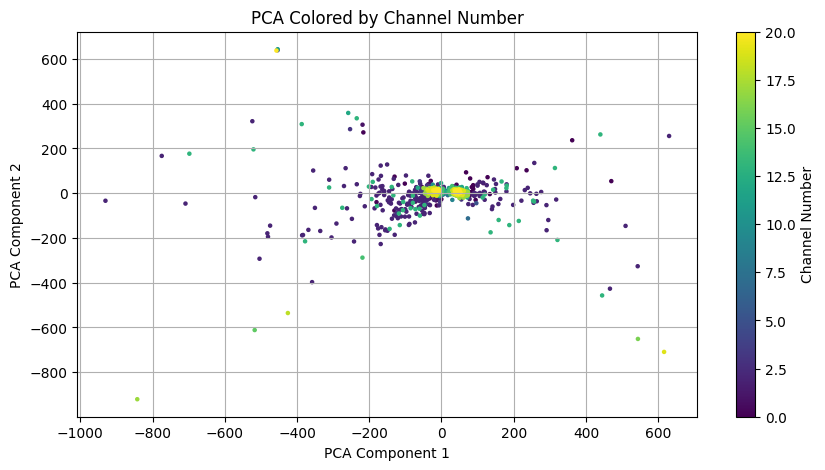

In [23]:
#replot the PCA plot and color by channel number
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
scatter = ax.scatter(pca_projections[:, 0], pca_projections[:, 1], c=all_chan_peaks[:, 0], cmap='viridis', s=5)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Channel Number')
ax.set_title('PCA Colored by Channel Number')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.grid()

## 13. Cluster Inspection

Examine the composition and waveforms of each K-Means cluster.

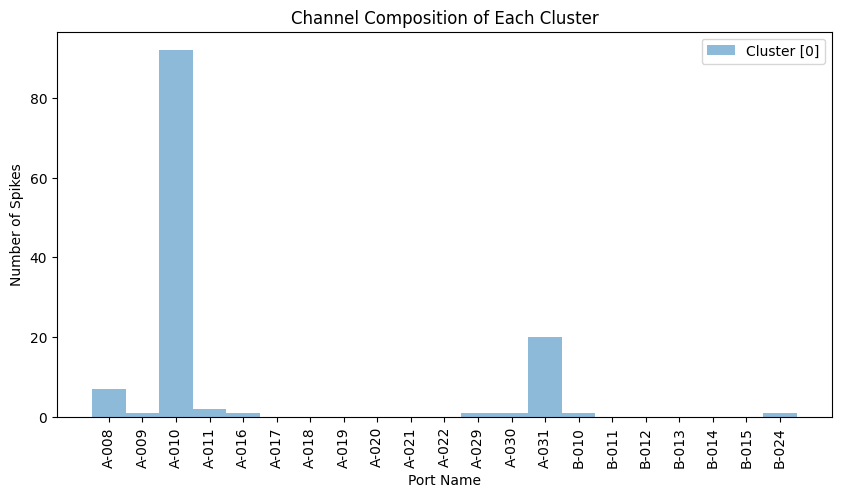

In [24]:
cluster_of_interest = [0]  # Example cluster index to analyze
#channel composition of each cluster
fig, ax = plt.subplots(1, 1, figsize=(10, 5)) 
cluster_channels = all_chan_peaks[np.isin(kmeans_labels, cluster_of_interest), 0]
ax.hist(cluster_channels, bins=np.arange(num_electrodes + 1) - 0.5, alpha=0.5, label=f'Cluster {cluster_of_interest}')
ax.set_xticks(np.arange(num_electrodes))
ax.set_xticklabels([electrodes_dict[i] for i in electrodes_dict.keys()], rotation=90)
ax.set_xlabel('Port Name')
ax.set_ylabel('Number of Spikes')
ax.set_title('Channel Composition of Each Cluster')
ax.legend()

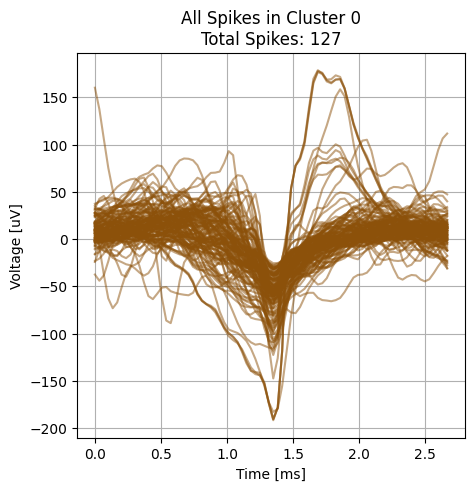

In [25]:
#plot all snips in one cluster
for c in cluster_of_interest:
    plt.figure(figsize=(5, 5))
    for i in range(len(snips)):
        if kmeans_labels[i] == c:
            l = len(snips[0])
            x = np.linspace(0, l, l) / fs * 1000
            plt.plot(x, snips[i], color=cmap(c), alpha=0.5)

    plt.xlabel('Time [ms]')
    plt.ylabel('Voltage [uV]')
    plt.grid()
    plt.title(f'All Spikes in Cluster {c}' '\n' f"Total Spikes: {np.sum(kmeans_labels == c)}")
    plt.savefig(os.path.join(out_dir, f"{experiment_name}_cluster_{c}_all_snips.png"), dpi=300)
    # if save_svg:
    #     plt.savefig(os.path.join(out_dir, f"{experiment_name}_cluster_{c}_all_snips.svg"))
    plt.show()

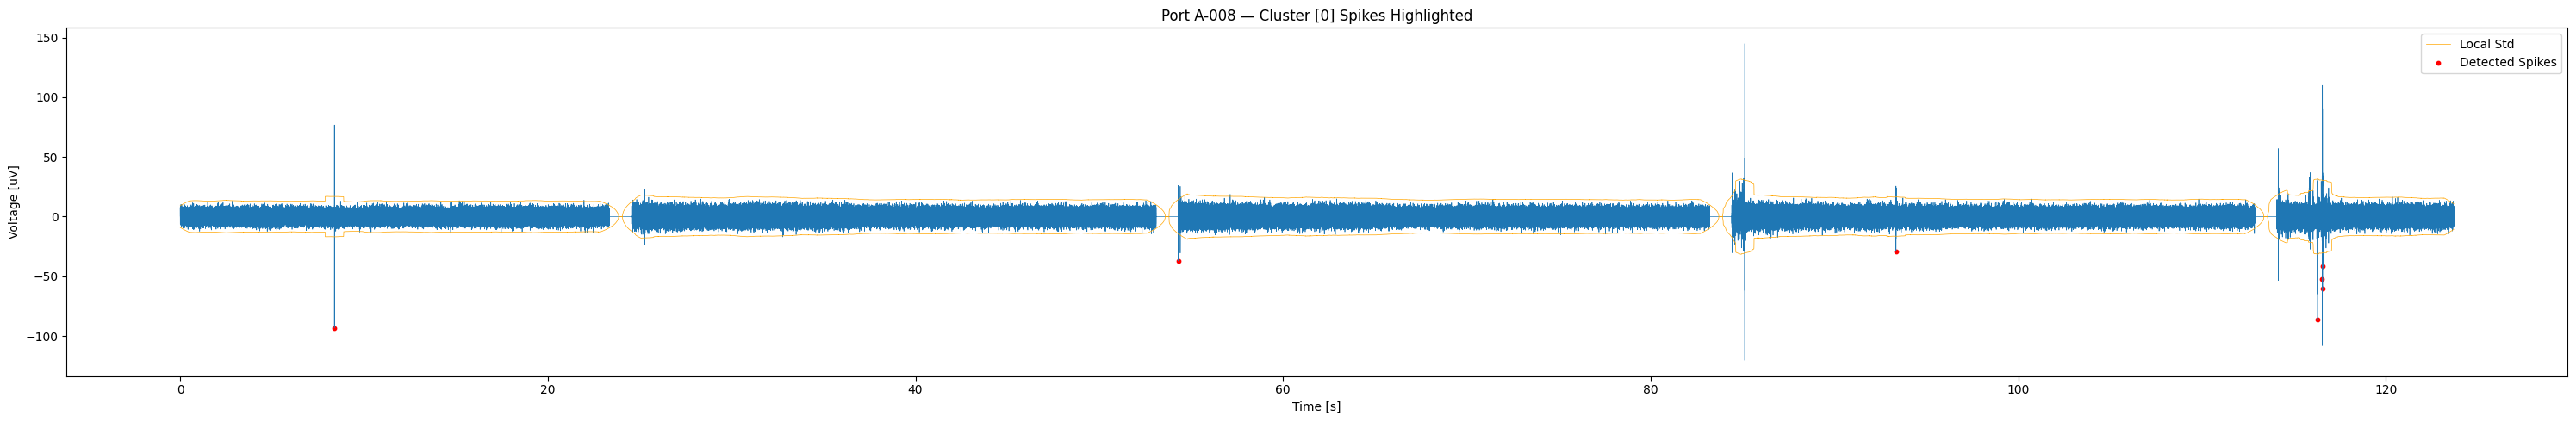

In [26]:
port = next(iter(electrodes_dict.values()))  # first available port
p = next(k for k, v in electrodes_dict.items() if v == port)

plt.figure(figsize=(30, 5))
plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1)
sig      = filtdata[p]
mean_sig = mean_local[:, p]
std_sig  = std_local[:, p]
length   = len(sig)
x = np.linspace(0, length, length) / fs
plt.plot(x, sig, lw=0.5)
plt.plot(x, mean_sig + std_threshold * std_sig, color="orange", lw=0.5, label="Local Std")
plt.plot(x, mean_sig - std_threshold * std_sig, color="orange", lw=0.5)

cluster_peaks = all_chan_peaks[np.isin(kmeans_labels, cluster_of_interest), :]
spike_times   = cluster_peaks[cluster_peaks[:, 0] == p, 1]
plt.scatter(spike_times / fs, sig[spike_times], color="red", s=10, label="Detected Spikes")

plt.xlabel("Time [s]")
plt.ylabel("Voltage [uV]")
plt.title(f"Port {port} — Cluster {cluster_of_interest} Spikes Highlighted")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, f"{experiment_name}_port_{port}_spikes_highlighted.png"), dpi=300)
plt.show()


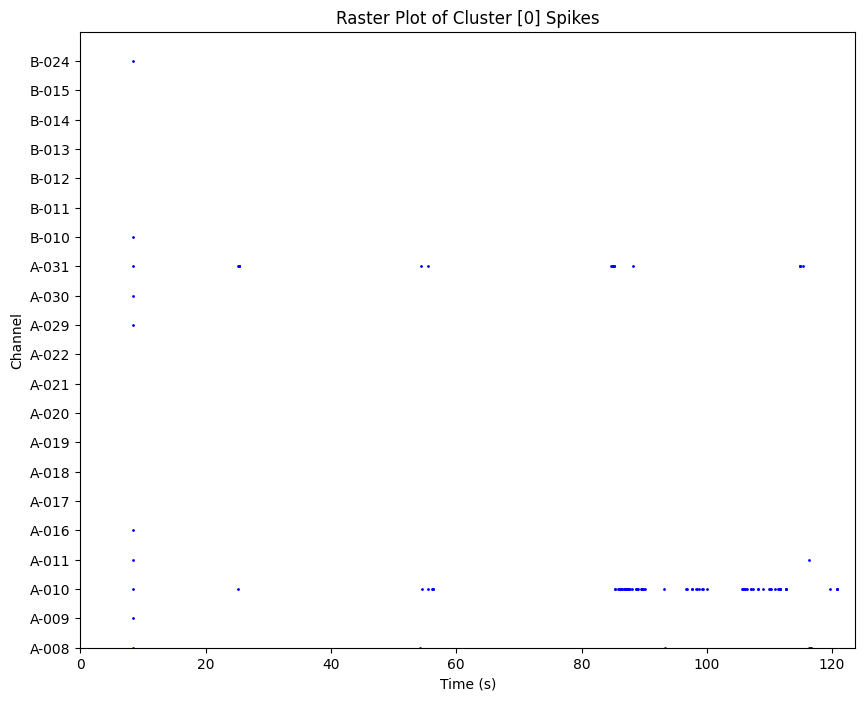

In [27]:
#plot cluster specific raster plot
plt.figure(figsize=(10, 8))
for i in range(len(all_chan_peaks)):
    if kmeans_labels[i] in cluster_of_interest:
        plt.scatter(all_chan_peaks[i, 1] / fs, all_chan_peaks[i, 0], color='blue', s=1)
plt.xlabel('Time (s)')
plt.ylabel('Channel')
plt.title(f'Raster Plot of Cluster {cluster_of_interest} Spikes')
#set y tick to show electrode number and port
yticks = np.arange(num_electrodes)
ytick_labels = [f'{electrodes_dict[i]}' for i in range(num_electrodes)]
plt.yticks(yticks, ytick_labels)
plt.xlim(0, len(filtdata[0])/fs)
plt.ylim(0, len(filtdata))
#if plotting stimulation windows
# if plot_stim_window:
#     for start, end in stim_windows:
#         plt.axvspan(start/fs, end/fs, color='red', alpha=0.2)
# plt.savefig(os.path.join(out_dir, f"{experiment_name}_cluster_{cluster_of_interest}_raster.png"), dpi=300)
# if save_svg:
#     plt.savefig(os.path.join(out_dir, f"{experiment_name}_cluster_{cluster_of_interest}_raster.svg"))
plt.show()

## 14. UMAP + DBSCAN (Optional)

Non-linear dimensionality reduction for exploring spike waveform structure. Requires `umap-learn` and `stumpy`.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


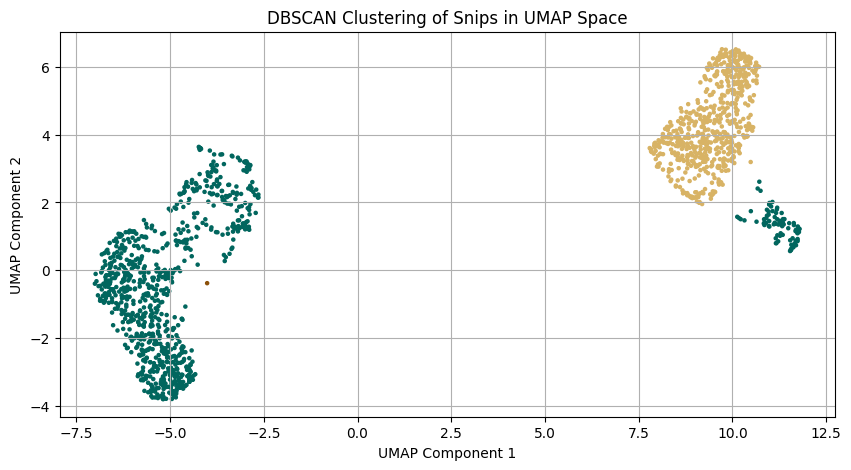

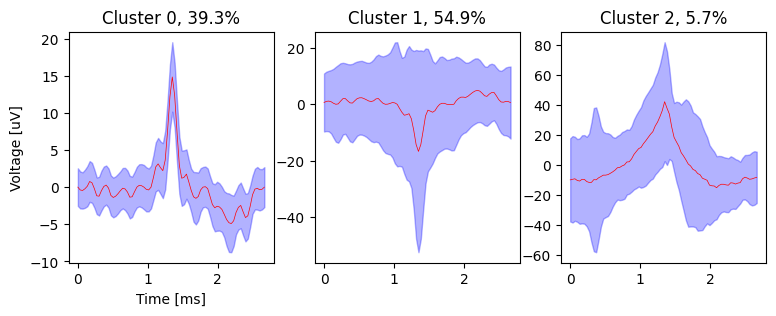

In [28]:
import stumpy
import umap
from sklearn.cluster import DBSCAN

#use UMAP for dimensionality reduction and visualization
reducer=umap.UMAP(n_components=2)
projections=reducer.fit_transform(snips)
clust=DBSCAN(eps=0.5)
clust.fit(projections)
is_clust=True
n_clusters=np.max(clust.labels_)+1
labs=clust.labels_

#plot the clusters in UMAP space
plt.figure(figsize=(10, 5))
scatter = plt.scatter(projections[:, 0], projections[:, 1], c=labs, cmap=cmap, s=5)
plt.title('DBSCAN Clustering of Snips in UMAP Space')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.grid()
plt.show()

if n_clusters!=0:
    fig,ax=plt.subplots(1,n_clusters, figsize=(n_clusters*3,3),sharex=True)
    for i in range(n_clusters):
        avg=np.median(snips[labs==i],axis=0)
        std=np.std(snips[labs==i],axis=0)
        l=len(snips[0])
        x=np.linspace(0,l,l)/30 #ms
        ax[i].fill_between(x,y1=avg-std,y2=avg+std,alpha=0.3,color='b')
        ax[i].plot(x,avg,color='r',linewidth=0.5)
        ax[i].set_title('Cluster '+str(i)+', '+str(np.round(100*np.sum(labs==i)/len(labs),1))+'%')
        ax[0].set_ylabel('Voltage [uV]')
        ax[0].set_xlabel('Time [ms]')

## 15. Export

Save spike cutouts and timestamps to `.npy` files for downstream analysis.

In [29]:
#export all snips
def save_spike_cutouts(all_chan_peaks, snips):
    spikes_dict = {}
    for chan in np.unique(all_chan_peaks[:, 0].astype(int)):
        idx = np.where(all_chan_peaks[:, 0] == chan)[0]
        sigs = snips[idx,] 
        spikes_dict[str(chan)] = sigs
    return spikes_dict

In [30]:
spikes_dict = save_spike_cutouts(all_chan_peaks, snips)

spike_filename = os.path.join(out_dir, f"{experiment_name}_all_spikes.npy")
spike_timepoints_filename = os.path.join(out_dir, f"{experiment_name}_all_spike_timepoints.npy")
electrode_dict_filname = os.path.join(out_dir, f"{experiment_name}_electrodelabel.npy")
#save spikes_dict to a npy file
np.save(spike_filename, spikes_dict)
np.save(spike_timepoints_filename, all_chan_peaks)
np.save(electrode_dict_filname, electrodes_dict)